### EDA

#### `describe()`

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the dataset
california = fetch_california_housing(as_frame=True)

# Convert the data to a Pandas DataFrame (optional, but often convenient)
df = pd.DataFrame(california.data, columns=california.feature_names)

# The 'Magic' Command
# Generates Count, Mean, Std, Min, 25%, 50%, 75%, Max
summary = df.describe()

print(summary)

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.429741     33.930000   -1

$$\mu = \frac{\sum_{i=1}^{n} x_i}{n}$$

In [2]:
# Using Pandas (Built on NumPy)
mean_income = df['MedInc'].mean()
house_age = df['HouseAge'].median()

print(f"Average Score: {mean_income}")
print(f"Middle Score: {house_age}")

Average Score: 3.8706710029069766
Middle Score: 29.0


$$\sigma = \sqrt{\frac{\sum(x_i - \mu)^2}{n}}$$

In [3]:
# Using Pandas (Built on NumPy)
std_income = df['MedInc'].std()

print(f"Standard Deviation of income: {std_income}")

Standard Deviation of income: 1.8998217179452688


$z = \frac{x - \mu}{\sigma}$

### Data Visualization with Matplotlib and Seaborn

In [ ]:
!pip install matplotlib seaborn 

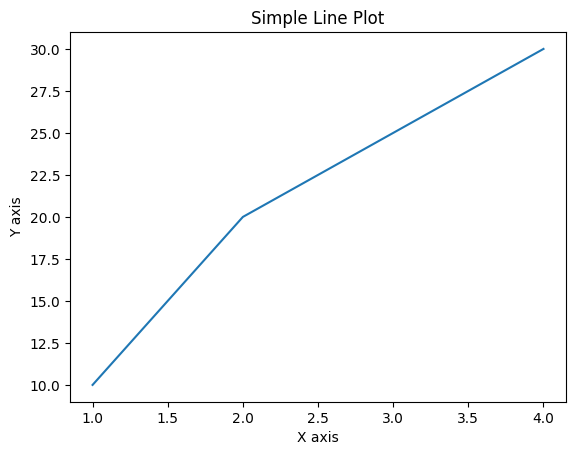

In [8]:
import matplotlib.pyplot as plt

# Data
x = [1, 2, 3, 4]
y = [10, 20, 25, 30]

# 1. Create a Figure and an Axes explicitly
fig, ax = plt.subplots()

# 2. Plot data on the Axes
ax.plot(x, y)

# 3. Set labels and title on the Axes
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_title("Simple Line Plot")

#save
plt.savefig('my_plot.png')
# 4. Render the Figure
plt.show()

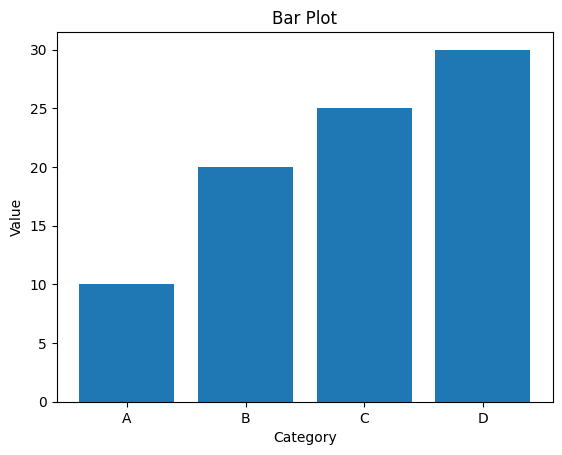

In [9]:
categories = ["A", "B", "C", "D"]
values = [10, 20, 25, 30]

fig, ax = plt.subplots()

ax.bar(categories, values)
ax.set_xlabel("Category")
ax.set_ylabel("Value")
ax.set_title("Bar Plot")

plt.show()

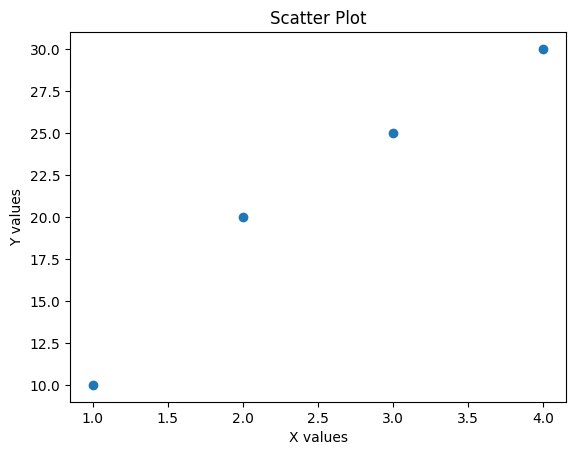

In [10]:
fig, ax = plt.subplots()

ax.scatter(x, y)
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Scatter Plot")

plt.show()

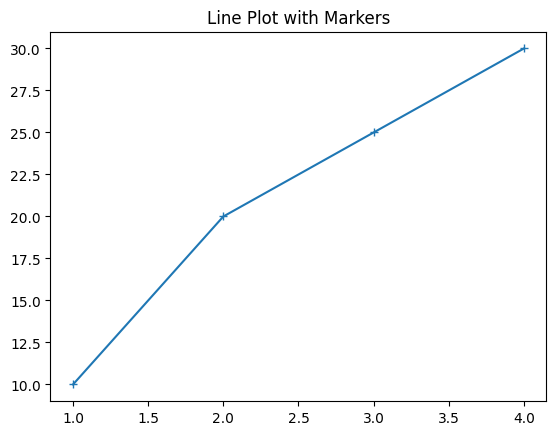

In [14]:
fig, ax = plt.subplots()

ax.plot(x, y, marker="+")
ax.set_title("Line Plot with Markers")

plt.show()

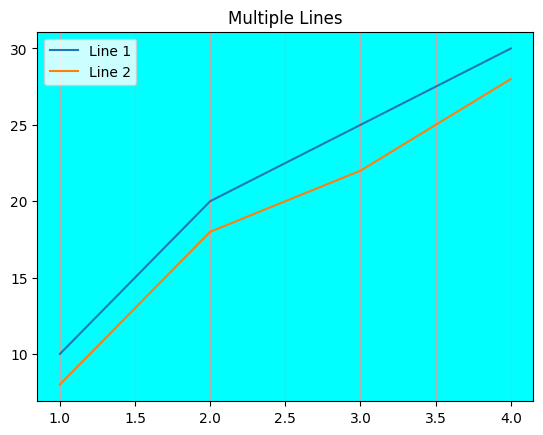

In [22]:
y2 = [8, 18, 22, 28]

fig, ax = plt.subplots()

ax.plot(x, y, label="Line 1")
ax.plot(x, y2, label="Line 2")

ax.patch.set_facecolor("lightgray")
ax.set_facecolor("aqua")
# ax.grid(True)
ax.grid(axis='x')

ax.set_title("Multiple Lines")
ax.legend()

plt.show()

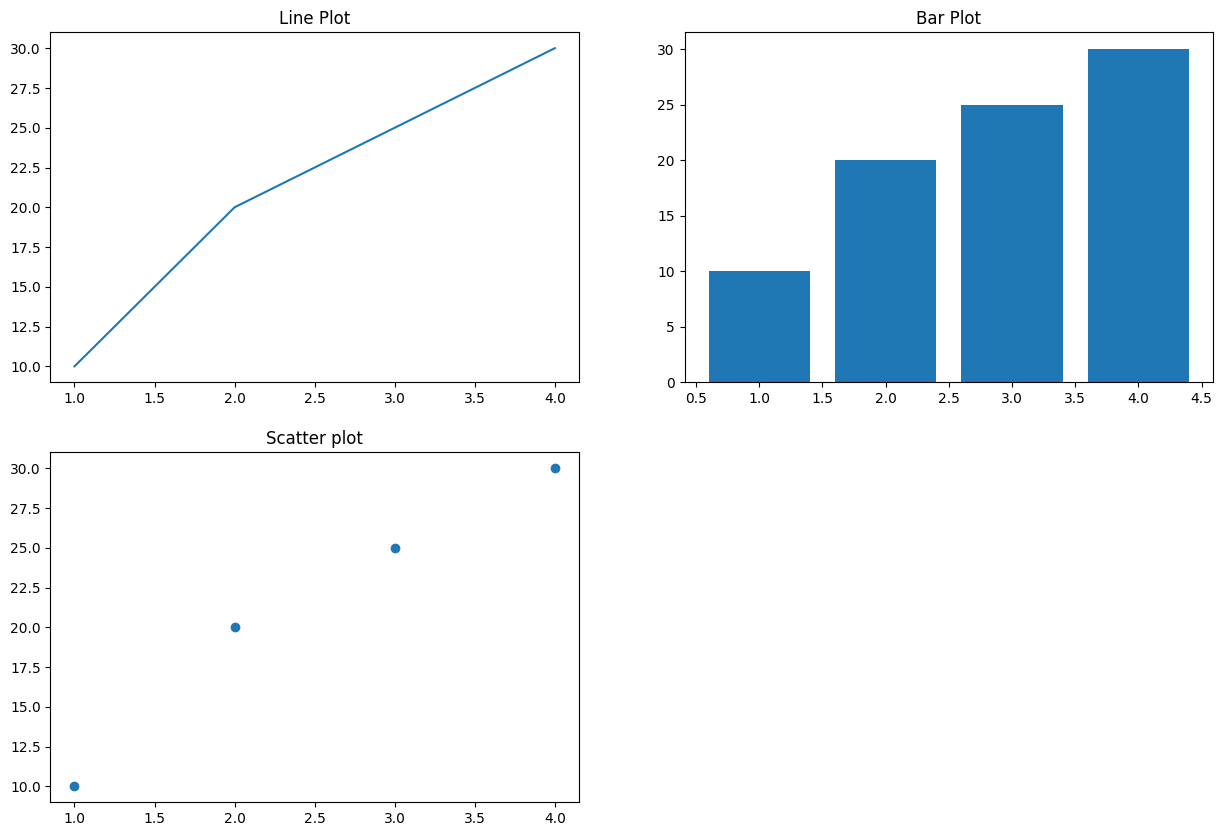

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) #(1-rows,2-columns)

axes[0][0].plot(x, y)
axes[0][0].set_title("Line Plot")

axes[0][1].bar(x, y)
axes[0][1].set_title("Bar Plot")

axes[1][0].scatter(x, y)
axes[1][0].set_title("Scatter plot")

axes[1][1].axis("off")


plt.show()

#### Seaborn

In [40]:
import pandas as pd
import numpy as np

# Create a small dataset
data = {
    "age": [23, 25, 31, 22, 28, 35, 30, 27, 40, 29],
    "salary": [40000, 42000, 58000, 39000, 52000, 75000, 60000, 50000, 90000, 62000],
    "gender": ["M", "F", "M", "F", "F", "M", "M", "F", "M", "F"],
    "department": ["HR", "Finance", "IT", "HR", "IT", "Finance", "IT", "HR", "Finance", "IT"],
    "years_experience": [1, 2, 5, 1, 4, 10, 6, 3, 15, 7]
}

df = pd.DataFrame(data)

# Quick look
print(df.head(2))


   age  salary gender department  years_experience
0   23   40000      M         HR                 1
1   25   42000      F    Finance                 2


In [ ]:
#seaborn line plot 
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=df, x="age", y="salary")
sns.set(style="whitegrid") 
plt.show()

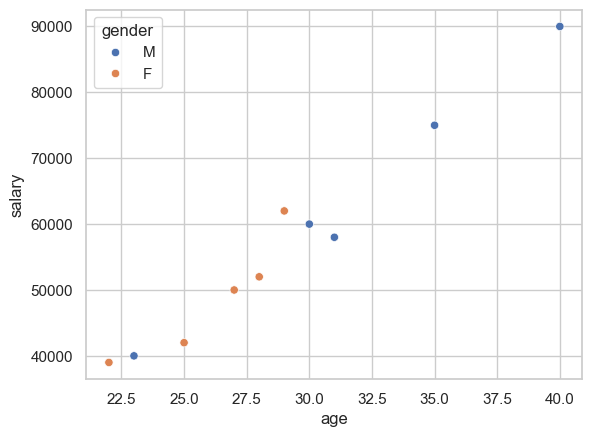

In [59]:
sns.scatterplot(
    data=df,
    x="age",
    y="salary",
    hue="gender"
)
plt.show()

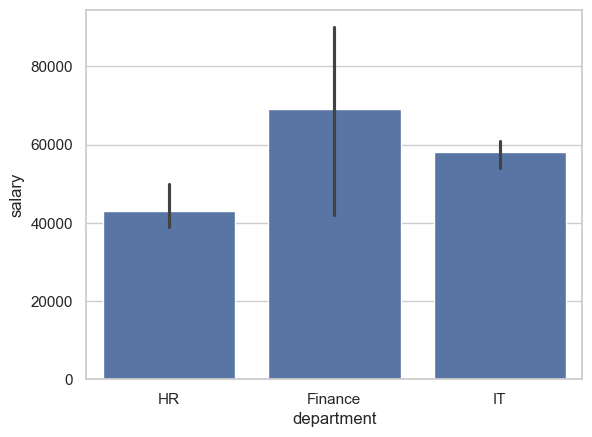

In [56]:
sns.barplot(data=df, x="department", y="salary")
plt.show()

In [ ]:
sns.histplot(data=df, 
            x="salary",
            bins=10,
            kde=True)

plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x="department", 
    y="salary")

plt.show()


$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$$

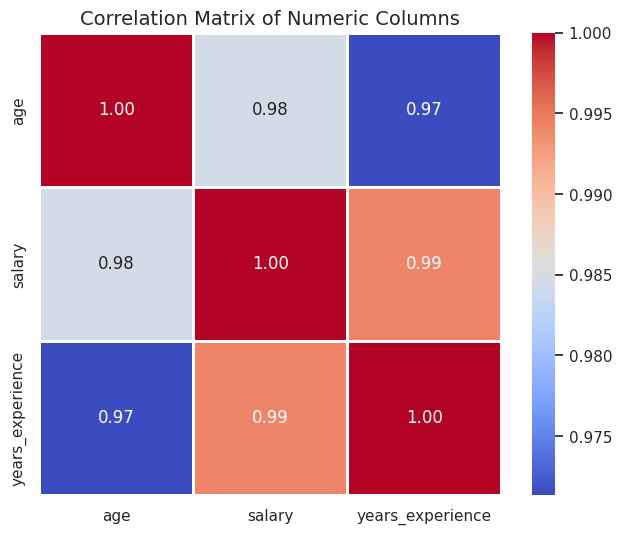

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Create a bigger figure for clarity
plt.figure(figsize=(8, 6))

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,       # write numbers in boxes
    cmap='coolwarm',  # color map
    linewidths=1,
    fmt=".2f",
    square=True
)
plt.title('Correlation Matrix of Numeric Columns', fontsize=14)
plt.show()


$$
\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$


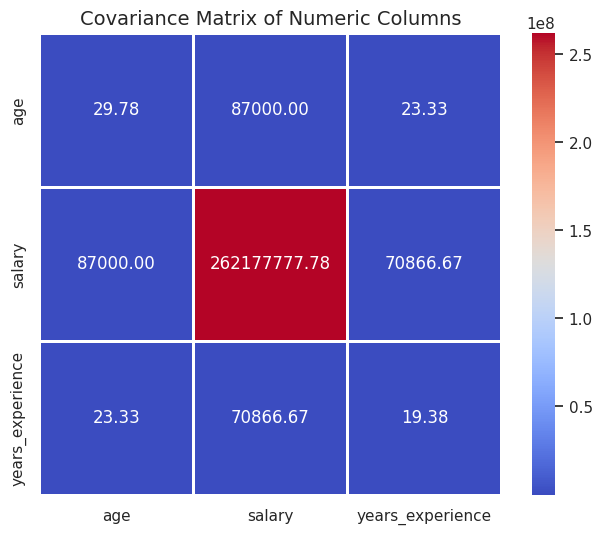

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate covariance matrix
cov_matrix = numeric_df.cov()

# Plot covariance matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cov_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt=".2f",
    square=True
)
plt.title('Covariance Matrix of Numeric Columns', fontsize=14)
plt.show()
